In [2]:
#librerias
import numpy as np, torch, torch.nn as nn, matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
torch.manual_seed(42); np.random.seed(42)
print('Librerías listas')

Librerías listas


/tmp/ipykernel_22779/1903425227.py:7: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.
  plt.xlabel('Día'); plt.ylabel('°C'); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


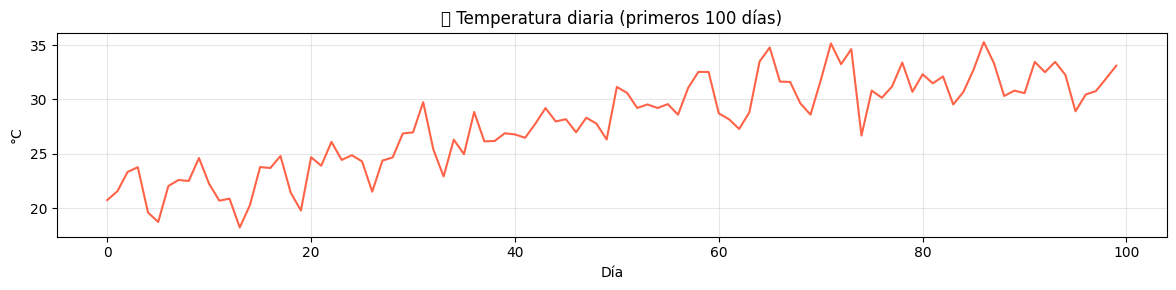

Min: 3.3°C | Max: 37.7°C | Media: 20.0°C


In [3]:
#simulacion de 2 años de la temperatura
t = np.arange(730)
temp = 20 + 12*np.sin(2*np.pi*t/365) + 2*np.sin(2*np.pi*t/7) + np.random.normal(0,1.5,730)

plt.figure(figsize=(12,3))
plt.plot(t[:100], temp[:100], color='tomato'); plt.title('🌡️ Temperatura diaria (primeros 100 días)')
plt.xlabel('Día'); plt.ylabel('°C'); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f'Min: {temp.min():.1f}°C | Max: {temp.max():.1f}°C | Media: {temp.mean():.1f}°C')

In [5]:
#preparacion para ventanas temporales
W = 14  # ventana de 14 días
scaler = MinMaxScaler(); serie = scaler.fit_transform(temp.reshape(-1,1)).flatten()

X = np.array([serie[i:i+W] for i in range(len(serie)-W)])
y = np.array([serie[i+W]   for i in range(len(serie)-W)])

sp = int(len(X)*0.8)
Xtr, Xte = torch.FloatTensor(X[:sp]).unsqueeze(-1), torch.FloatTensor(X[sp:]).unsqueeze(-1)
ytr, yte = torch.FloatTensor(y[:sp]), torch.FloatTensor(y[sp:])
loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=32, shuffle=True)
print(f'Train: {Xtr.shape} | Test: {Xte.shape}')

Train: torch.Size([572, 14, 1]) | Test: torch.Size([144, 14, 1])


In [7]:
#modelo transformer
class Atencion(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(d, d//2), nn.Tanh(), nn.Linear(d//2, 1))
    def forward(self, x):
        w = torch.softmax(self.fc(x).squeeze(-1), dim=1)   # pesos de atención
        return (w.unsqueeze(-1)*x).sum(dim=1), w            # contexto + pesos

class TransformerSimple(nn.Module):
    def __init__(self, d=32):
        super().__init__()
        self.enc  = nn.Linear(1, d)
        self.norm = nn.LayerNorm(d)
        self.attn = Atencion(d)
        self.out  = nn.Sequential(nn.Linear(d, d//2), nn.ReLU(), nn.Dropout(0.1), nn.Linear(d//2, 1))
    def forward(self, x):
        h = torch.relu(self.norm(self.enc(x)))
        ctx, w = self.attn(h)
        return self.out(ctx).squeeze(-1), w

class LSTM(nn.Module):
    def __init__(self, d=32):
        super().__init__()
        self.rnn = nn.LSTM(1, d, batch_first=True)
        self.fc  = nn.Linear(d, 1)
    def forward(self, x):
        o, _ = self.rnn(x); return self.fc(o[:,-1,:]).squeeze(-1)

print('Modelos definidos')
print(f'   Transformer parámetros: {sum(p.numel() for p in TransformerSimple().parameters()):,}')
print(f'   LSTM parámetros:        {sum(p.numel() for p in LSTM().parameters()):,}')

Modelos definidos
   Transformer parámetros: 1,218
   LSTM parámetros:        4,513


Entrenando Transformer...
Entrenando LSTM...


/tmp/ipykernel_22779/3259832031.py:22: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


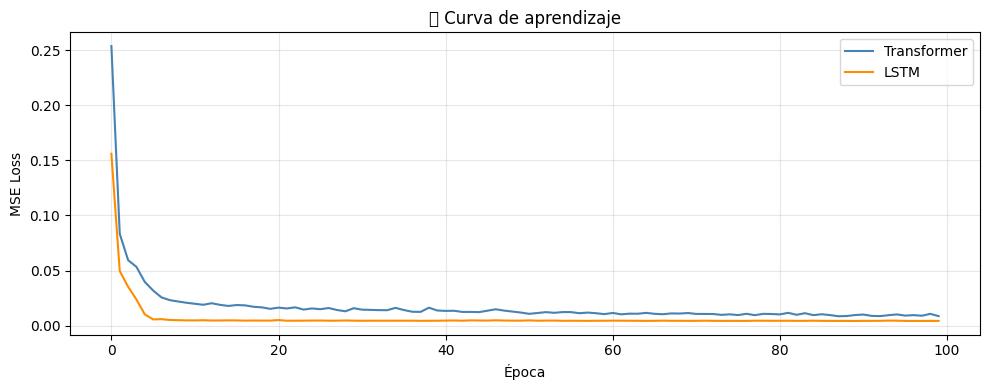

Entrenamiento completado


In [8]:
#entrenamiento del modelo
def entrenar(modelo, loader, epocas=100, lr=0.001, es_transformer=True):
    opt = torch.optim.Adam(modelo.parameters(), lr=lr)
    crit = nn.MSELoss(); losses = []
    for _ in range(epocas):
        modelo.train(); lt = 0
        for Xb, yb in loader:
            opt.zero_grad()
            pred = modelo(Xb)[0] if es_transformer else modelo(Xb)
            l = crit(pred, yb); l.backward(); opt.step(); lt += l.item()
        losses.append(lt/len(loader))
    return losses

trf = TransformerSimple(); lstm = LSTM()
print('Entrenando Transformer...'); loss_trf  = entrenar(trf,  loader, es_transformer=True)
print('Entrenando LSTM...');        loss_lstm = entrenar(lstm, loader, es_transformer=False)

plt.figure(figsize=(10,4))
plt.plot(loss_trf,  label='Transformer', color='steelblue')
plt.plot(loss_lstm, label='LSTM',        color='darkorange')
plt.title('📉 Curva de aprendizaje'); plt.xlabel('Época'); plt.ylabel('MSE Loss')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print('Entrenamiento completado')

Transformer  → MAE: 1.934°C | RMSE: 2.395°C
LSTM         → MAE: 1.805°C | RMSE: 2.262°C


/tmp/ipykernel_22779/2037355799.py:22: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


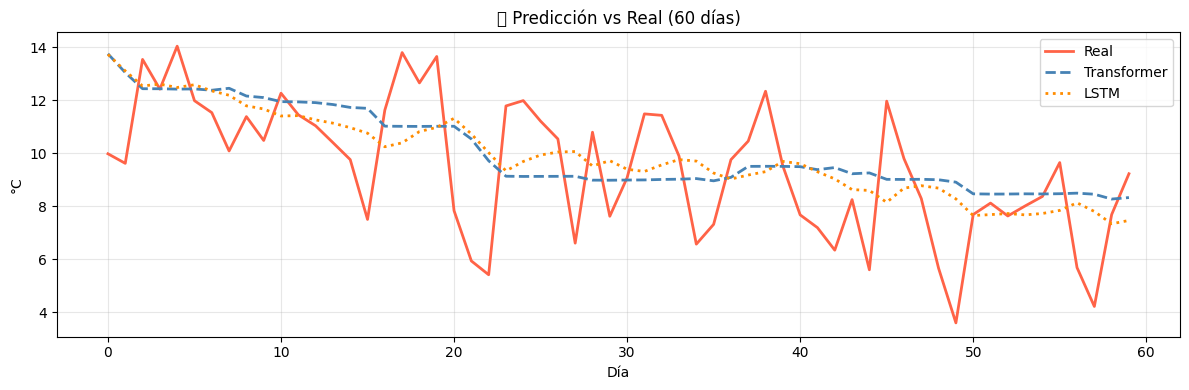

In [9]:
def evaluar(modelo, Xte, yte, es_transformer=True):
    modelo.eval()
    with torch.no_grad():
        p = modelo(Xte)[0] if es_transformer else modelo(Xte)
    pr = scaler.inverse_transform(p.numpy().reshape(-1,1)).flatten()
    yr = scaler.inverse_transform(yte.numpy().reshape(-1,1)).flatten()
    return pr, yr

p_trf,  yr = evaluar(trf,  Xte, yte, True)
p_lstm, _  = evaluar(lstm, Xte, yte, False)

for nombre, pred in [('Transformer', p_trf), ('LSTM', p_lstm)]:
    mae  = mean_absolute_error(yr, pred)
    rmse = np.sqrt(mean_squared_error(yr, pred))
    print(f'{nombre:12s} → MAE: {mae:.3f}°C | RMSE: {rmse:.3f}°C')

plt.figure(figsize=(12,4))
plt.plot(yr[:60],     label='Real',        color='tomato',     lw=2)
plt.plot(p_trf[:60],  label='Transformer', color='steelblue',  lw=2, ls='--')
plt.plot(p_lstm[:60], label='LSTM',        color='darkorange', lw=2, ls=':')
plt.title('🌡️ Predicción vs Real (60 días)'); plt.xlabel('Día'); plt.ylabel('°C')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

/tmp/ipykernel_22779/3319081416.py:21: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_22779/3319081416.py:21: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()


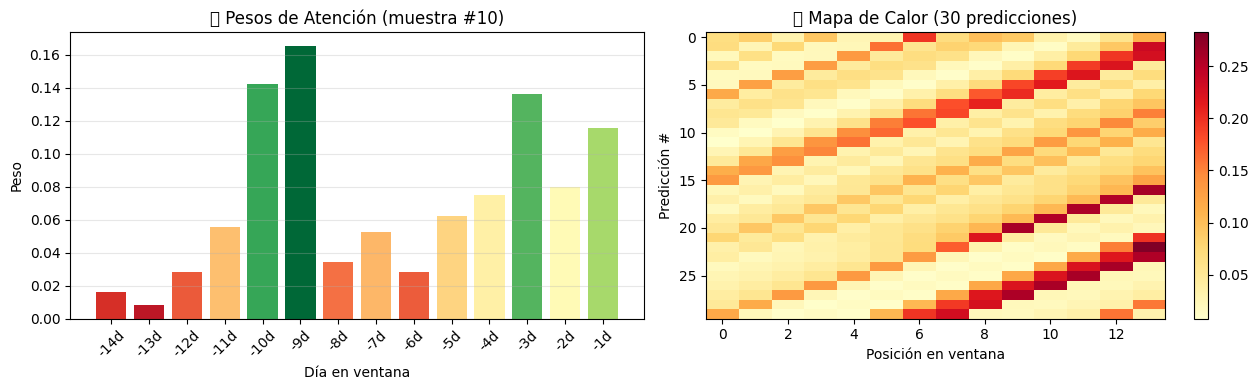

📌 En promedio, el modelo presta más atención al día -14 (posición 0)


In [12]:
#visualizacion de pesos
trf.eval()
with torch.no_grad():
    _, pesos = trf(Xte)
pesos_np = pesos.numpy()   # (n_test, 14)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Barras: pesos para un ejemplo
dias = [f'-{W-i}d' for i in range(W)]
axes[0].bar(dias, pesos_np[10], color=plt.cm.RdYlGn(pesos_np[10]/pesos_np[10].max()))
axes[0].set_title('🔍 Pesos de Atención (muestra #10)'); axes[0].set_xlabel('Día en ventana')
axes[0].set_ylabel('Peso'); axes[0].tick_params(axis='x', rotation=45); axes[0].grid(alpha=0.3, axis='y')

# Mapa de calor
im = axes[1].imshow(pesos_np[:30], aspect='auto', cmap='YlOrRd')
axes[1].set_title('🗺️ Mapa de Calor (30 predicciones)')
axes[1].set_xlabel('Posición en ventana'); axes[1].set_ylabel('Predicción #')
plt.colorbar(im, ax=axes[1])

plt.tight_layout(); plt.show()

idx_max = pesos_np.mean(axis=0).argmax()
print(f'📌 En promedio, el modelo presta más atención al día -{W-idx_max} (posición {idx_max})')

/tmp/ipykernel_22779/1314900645.py:28: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.xticks(ventanas); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


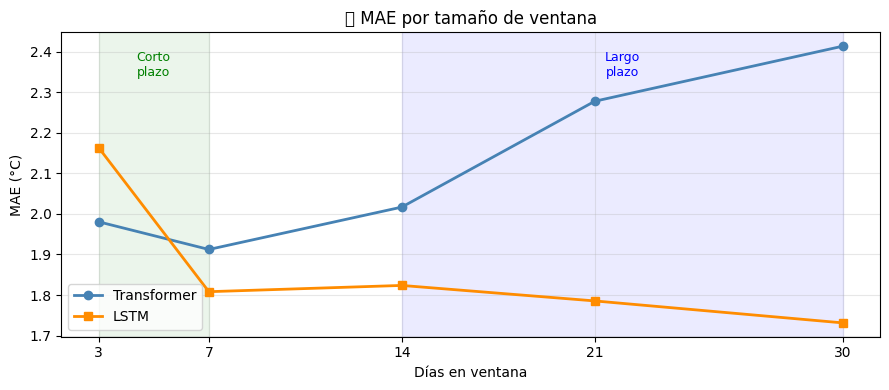

In [14]:
#dependencias a corto y largo plazo
ventanas = [3, 7, 14, 21, 30]
res = {'Transformer': [], 'LSTM': []}

for ws in ventanas:
    Xw = np.array([serie[i:i+ws] for i in range(len(serie)-ws)])
    yw = np.array([serie[i+ws]   for i in range(len(serie)-ws)])
    sp2 = int(len(Xw)*0.8)
    Xw_te = torch.FloatTensor(Xw[sp2:]).unsqueeze(-1)
    yw_te = yw[sp2:]
    dl2 = DataLoader(TensorDataset(torch.FloatTensor(Xw[:sp2]).unsqueeze(-1),
                                   torch.FloatTensor(yw[:sp2])), batch_size=32, shuffle=True)
    for nombre, Cls, es_t in [('Transformer', TransformerSimple, True), ('LSTM', LSTM, False)]:
        m = Cls(); entrenar(m, dl2, epocas=50, es_transformer=es_t)
        m.eval()
        with torch.no_grad():
            p = m(Xw_te)[0] if es_t else m(Xw_te)
        pr = scaler.inverse_transform(p.numpy().reshape(-1,1)).flatten()
        yr2 = scaler.inverse_transform(yw_te.reshape(-1,1)).flatten()
        res[nombre].append(mean_absolute_error(yr2, pr))

plt.figure(figsize=(9,4))
plt.plot(ventanas, res['Transformer'], 'o-', color='steelblue',  lw=2, label='Transformer')
plt.plot(ventanas, res['LSTM'],        's-', color='darkorange', lw=2, label='LSTM')
plt.axvspan(3, 7,  alpha=0.08, color='green'); plt.text(5,  max(max(res['Transformer']),max(res['LSTM']))*0.97,'Corto\nplazo', ha='center', color='green', fontsize=9)
plt.axvspan(14,30, alpha=0.08, color='blue');  plt.text(22, max(max(res['Transformer']),max(res['LSTM']))*0.97,'Largo\nplazo', ha='center', color='blue',  fontsize=9)
plt.title('📈 MAE por tamaño de ventana'); plt.xlabel('Días en ventana'); plt.ylabel('MAE (°C)')
plt.xticks(ventanas); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

El mecanismo de atención permite al modelo identificar que días del pasado son más relevantes para predecir el futuro, superando la limitación del LSTM de olvidar información lejana.

| Criterio | LSTM | Transformer |
|---|---|---|
| Dependencias largas | Se degrada | Acceso directo |
| Paralelización | Secuencial | Paralelo |
| Interpretabilidad | Caja negra | Pesos visibles |
| Datos pequeños | Estable | Puede sobreajustar |
| Escala con más datos | Más lento | Eficiente |